<a href="https://colab.research.google.com/github/Hend-Cheikhrouhou/Machine_Learning/blob/main/R%C3%A9seaux_de_Neurones_%E2%80%93_Pr%C3%A9diction_d%E2%80%99AVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implémentation d’un Perceptron Multi Couches (PMC) avec Python (TensorFlow et Keras) </u></h2>

<p style ="font-size:18px"> On s'intéresse à la prédiction d'AVC ( Accident Cardio-Vasculaire) à l'aide d'un réseau de neurones en python. Dans un premier temps on importe les données et on les visualise.</p>


In [ ]:
import pandas as pd
data=pd.read_csv('/content/DATA DEEP LEARNING.txt')

data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
import warnings
warnings.filterwarnings('ignore')

**Activité1**:



1.   Explorez le dataset : taille, informations sur les variables indépendantes et les variables dépendantes
2.   Effectuez une AED

In [ ]:
# Explorer la taille du dataset
print("Taille du dataset :", data.shape)

Taille du dataset : (5110, 12)


In [ ]:
# Informations sur les variables
print("\nInformations sur les variables :")
print(data.info())


Informations sur les variables :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [ ]:
# Statistiques descriptives pour les variables numériques
print("\nStatistiques descriptives pour les variables numériques :")
print(data.describe())


Statistiques descriptives pour les variables numériques :
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000

In [ ]:
data["gender"].value_counts()

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [ ]:
data["hypertension"].value_counts()

0    4612
1     498
Name: hypertension, dtype: int64

In [ ]:
import seaborn as sns

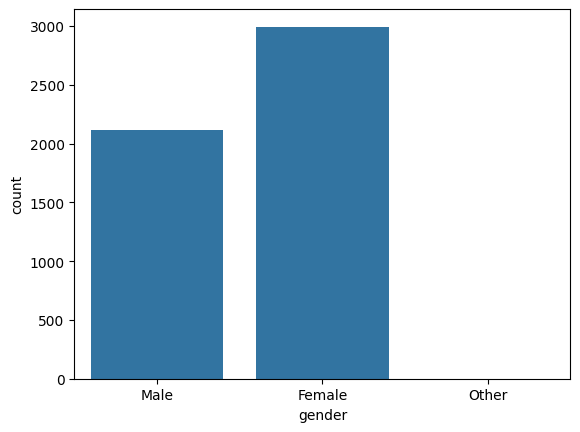

In [ ]:
sns.countplot(x='gender', data = data);

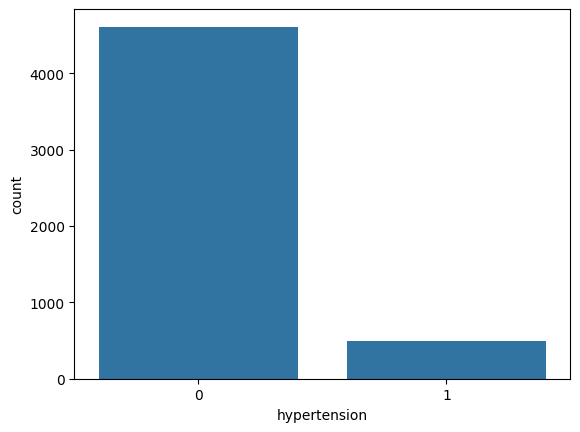

In [ ]:
sns.countplot(x='hypertension', data = data);

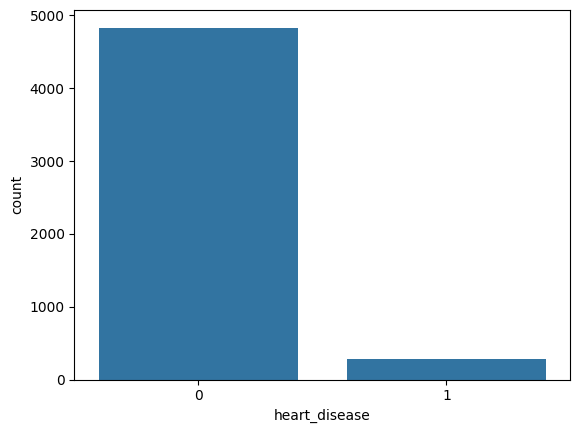

In [ ]:
sns.countplot(x='heart_disease', data = data);

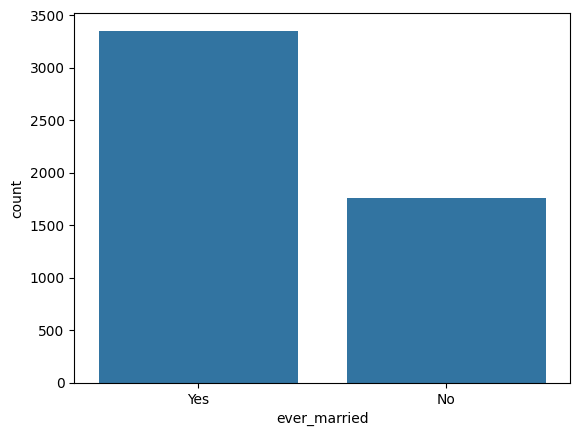

In [ ]:
sns.countplot(x='ever_married', data = data);

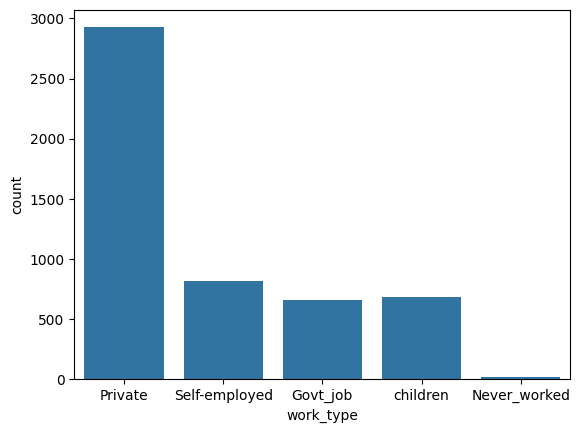

In [ ]:
sns.countplot(x='work_type', data = data);

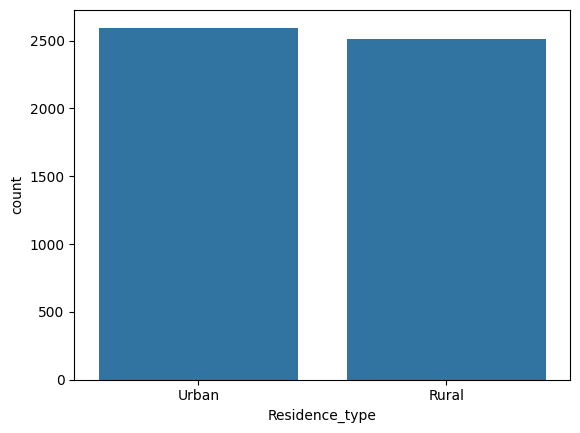

In [ ]:
sns.countplot(x='Residence_type', data = data);

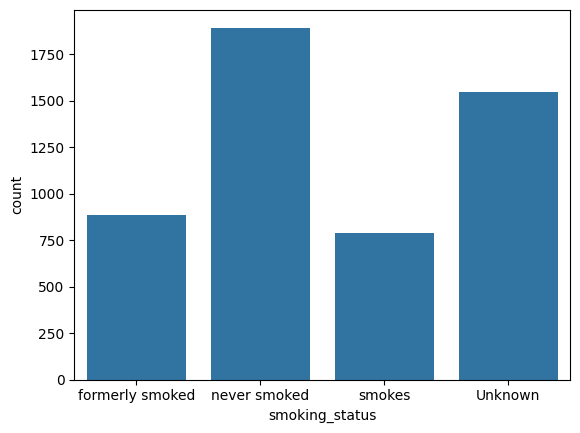

In [ ]:
sns.countplot(x='smoking_status', data = data);

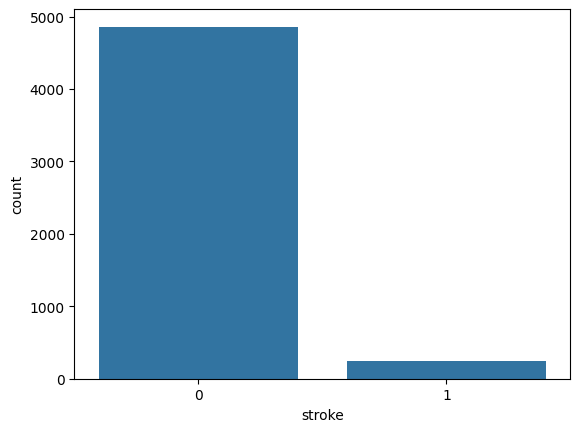

In [ ]:
sns.countplot(x='stroke', data = data);

<Axes: ylabel='age'>

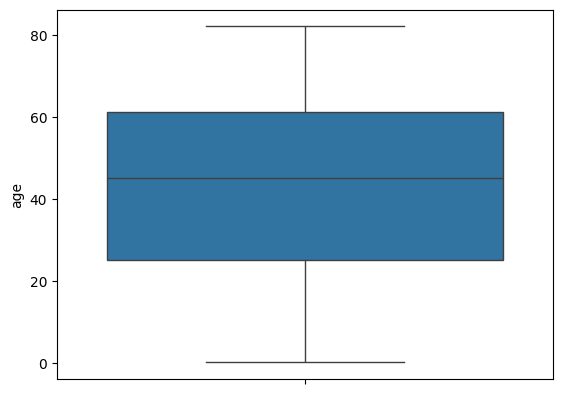

In [ ]:
sns.boxplot(data["age"])

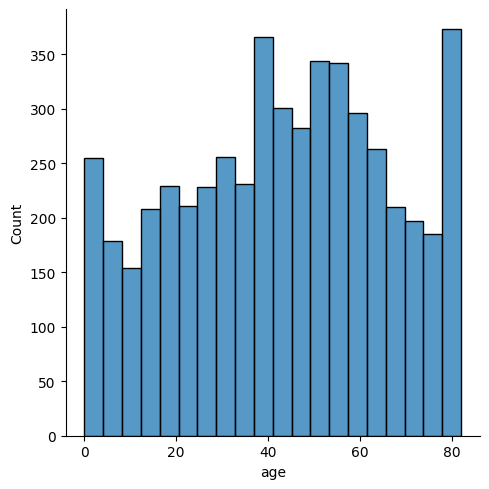

In [ ]:
sns.displot(data["age"]);

<Axes: ylabel='avg_glucose_level'>

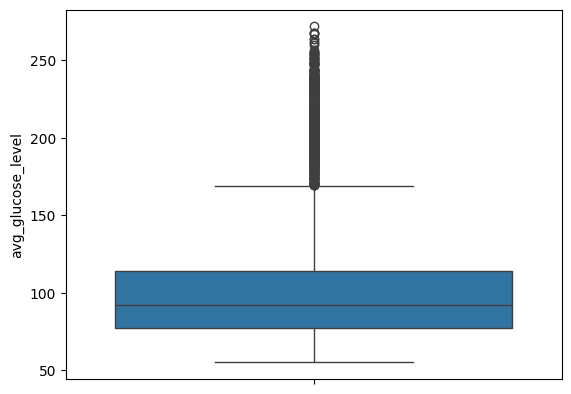

In [ ]:
sns.boxplot(data["avg_glucose_level"])

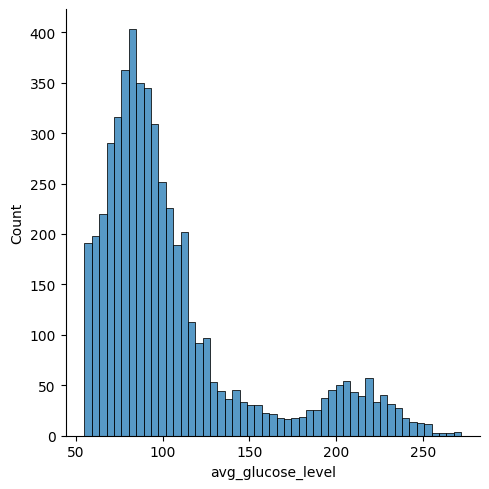

In [ ]:
sns.displot(data["avg_glucose_level"]);

<Axes: ylabel='bmi'>

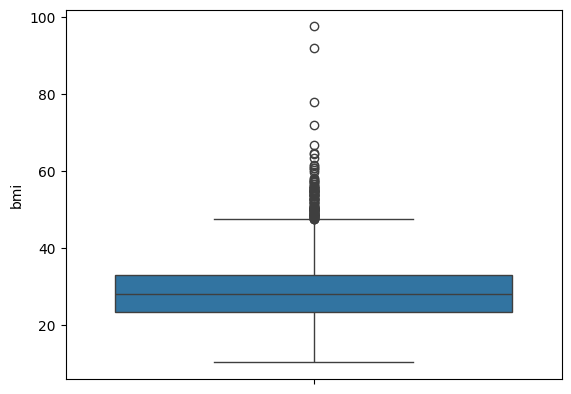

In [ ]:
sns.boxplot(data["bmi"])

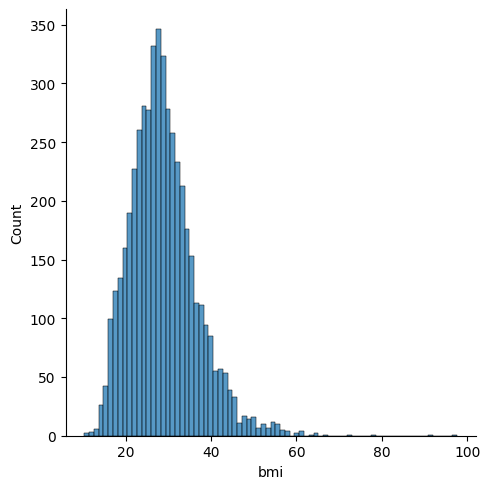

In [ ]:
sns.displot(data["bmi"]);

analyse bivariée

<Axes: title={'center': 'age'}, xlabel='hypertension'>

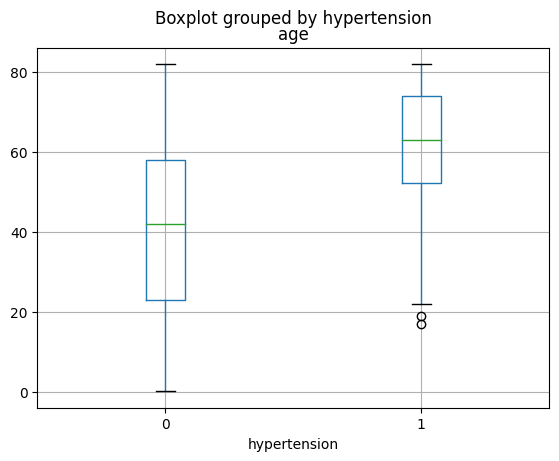

In [ ]:
# c'est une analyse bi-variée entre age et hypertension
data.boxplot(column='age',by="hypertension" )

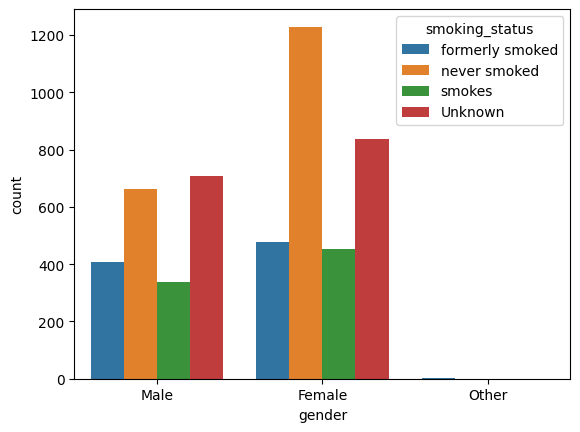

In [ ]:
#smoking_status
sns.countplot(x='gender', hue='smoking_status', data=data, linewidth=5);

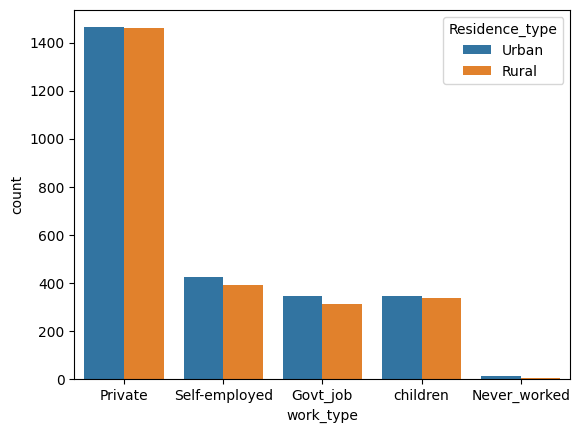

In [ ]:
#work_type
sns.countplot(x='work_type', hue='Residence_type', data=data, linewidth=5);

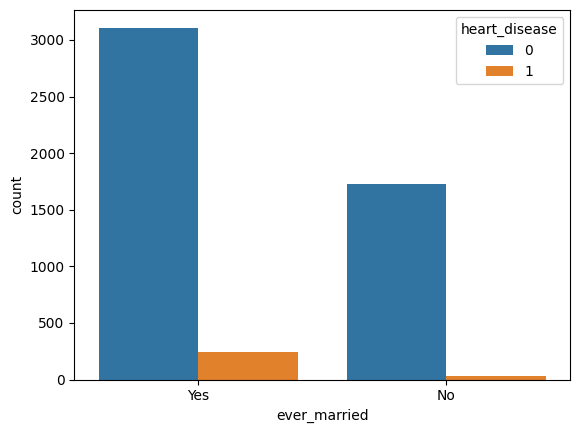

In [ ]:
#heart_disease
sns.countplot(x='ever_married', hue='heart_disease', data=data, linewidth=5);

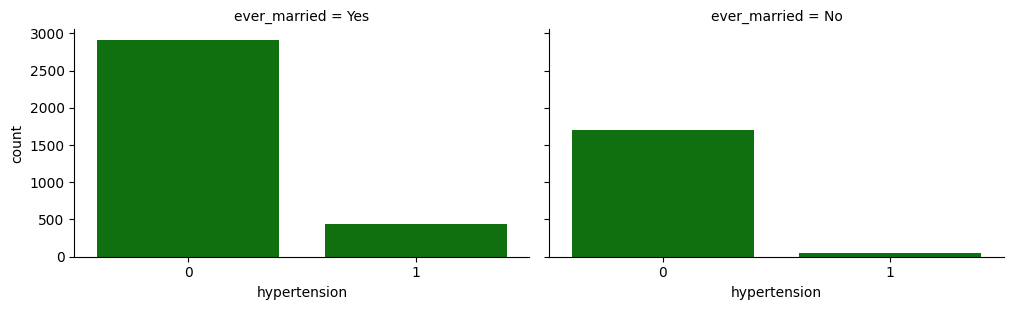

In [ ]:
grid = sns.FacetGrid(data,col='ever_married', height =3.2, aspect=1.6)
grid.map(sns.countplot, 'hypertension', color="green")

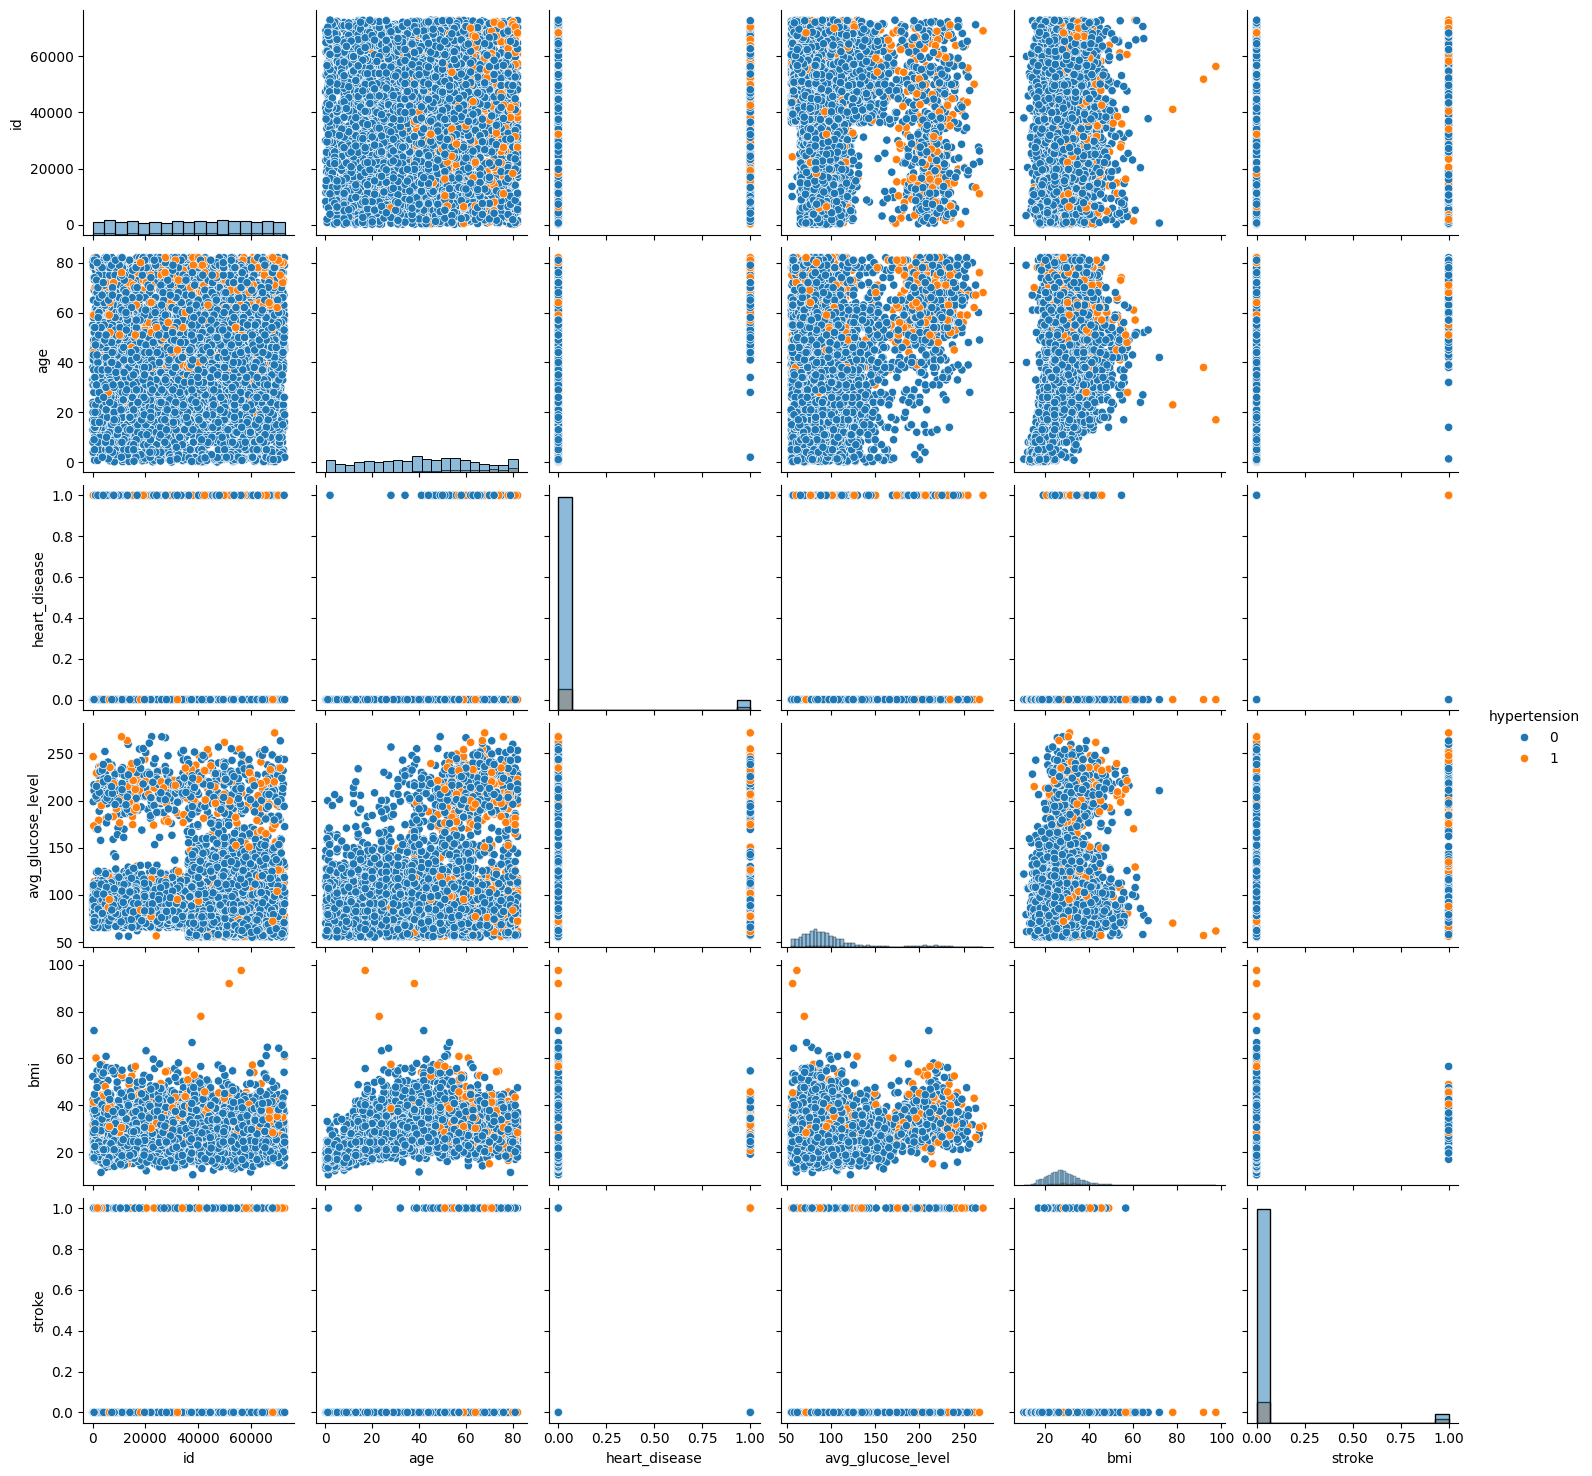

In [ ]:
sns.pairplot(data, hue="hypertension",diag_kind="hist" )

Remarque: je remarque que dans cette cas il faut integrer le Deep learning.

Analyse de correlation


In [ ]:
#importer les packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np

# Remplacer les valeurs manquantes par une valeur sentinelle
data_cleaned = np.nan_to_num(data, nan=-9999)

# Découvrir les valeurs manquantes
missing_values = (data_cleaned == -9999).sum(axis=0)

print("Nombre de valeurs manquantes par colonne :")
print(missing_values)

Nombre de valeurs manquantes par colonne :
[0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
#supprimer les valeurs manquantes
data.dropna(inplace=True)
data.shape

(4909, 12)

In [ ]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [ ]:
# Calculer la matrice de corrélation
correlation_matrix = data.corr()

# Afficher la matrice de corrélation
print(correlation_matrix)

                         id       age  hypertension  heart_disease  \
id                 1.000000  0.008984      0.001147       0.004016   
age                0.008984  1.000000      0.274425       0.257123   
hypertension       0.001147  0.274425      1.000000       0.115991   
heart_disease      0.004016  0.257123      0.115991       1.000000   
avg_glucose_level  0.006409  0.235838      0.180543       0.154525   
bmi                0.003084  0.333398      0.167811       0.041357   
stroke             0.004839  0.232331      0.142515       0.137938   

                   avg_glucose_level       bmi    stroke  
id                          0.006409  0.003084  0.004839  
age                         0.235838  0.333398  0.232331  
hypertension                0.180543  0.167811  0.142515  
heart_disease               0.154525  0.041357  0.137938  
avg_glucose_level           1.000000  0.175502  0.138936  
bmi                         0.175502  1.000000  0.042374  
stroke                    

<Axes: >

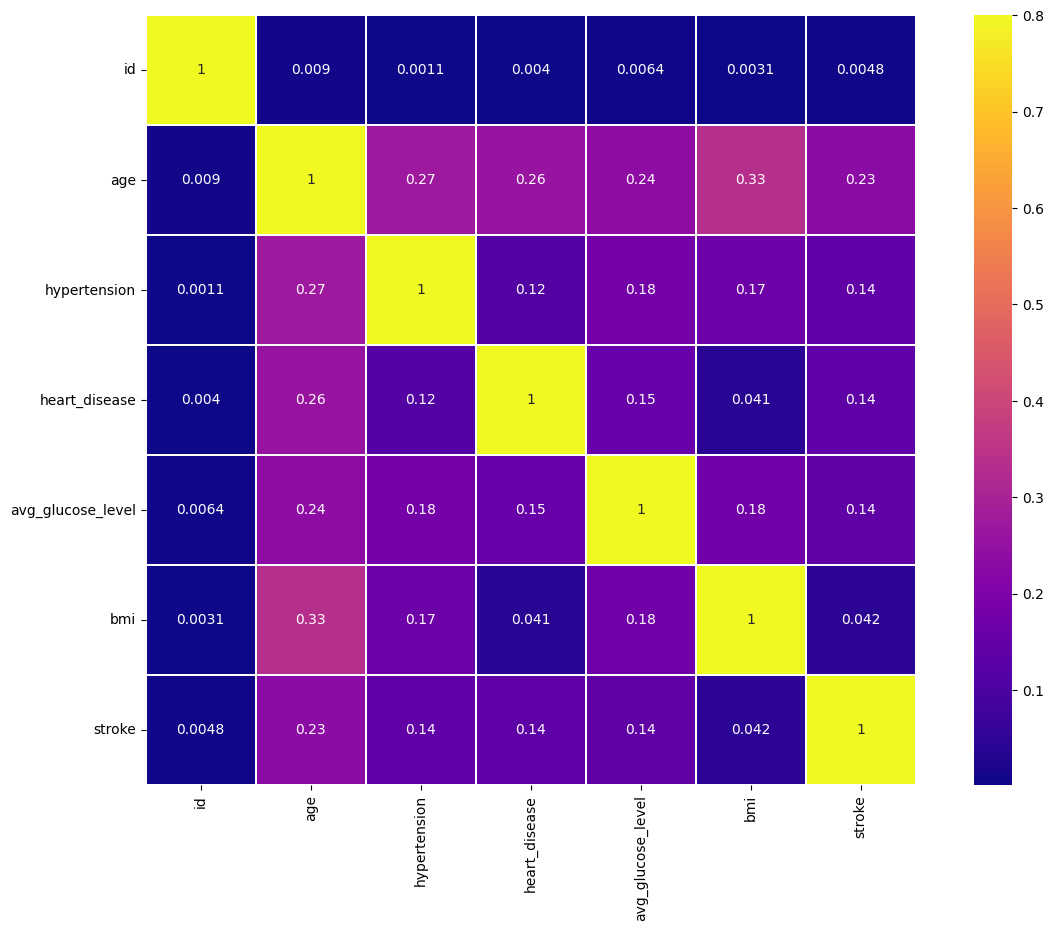

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#sns.heatmap(data.corr()) ou
#plt.figure(figsize=(15, 10)) #vous pouvez utiliser cette instruction pour gérer la taille de la matrice
numeric_columns=data.select_dtypes(include=[int,float])
plt.figure(figsize=(15, 10))
matrix = data.corr()
sns.heatmap(matrix, vmax=.8, square=True, cmap="plasma", annot=True, linewidths=.1)

interpretation de la matrice de corrlation:
-une correlation positive:
*il existe une forte corrlation positive entre variable age et ever_married de 28%.
*il existe une faible correlation positive entre variable ever_married et hypertension de 16%.
-une correlation négative: il existe une correlation negative entre variable smoking_status et work type de 31%.
-une corrélation pure et parfaite entre le variable lui meme.


<p style ="font-size:18px"> Dans un second temps, on effectue un prétraitement des données. On supprime les données manquantes, on supprime la colonne id qui ne nous intéresse pas et on encode les données non numériques.</p>

In [ ]:
# transformer des données non numériques en valeurs numériques
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['gender'] = label_encoder.fit_transform(data['gender'])
data['ever_married'] = label_encoder.fit_transform(data['ever_married'])
data['work_type'] = label_encoder.fit_transform(data['work_type'])
data['Residence_type'] = label_encoder.fit_transform(data['Residence_type'])
data['smoking_status'] = label_encoder.fit_transform(data['smoking_status'])

In [ ]:
# Supprimer la colonne "id" du DataFrame original
if 'id' in data.columns:
    print("Column 'id' exists in the DataFrame")
else:
    print("Column 'id' does not exist in the DataFrame")
if 'id' in data.columns:
    data.drop(columns=['id'], inplace=True)
    print("Column 'id' has been dropped from the DataFrame")
else:
    print("Column 'id' does not exist in the DataFrame, so it cannot be dropped")

Column 'id' exists in the DataFrame
Column 'id' has been dropped from the DataFrame


In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# Calculer la corrélation entre les variables et effectuer les tests statistiques
correlation_tests = {}
for column1 in data.columns:
    for column2 in data.columns:
        if column1 != column2:  # Éviter de calculer la corrélation d'une variable avec elle-même
            correlation_coefficient, p_value = pearsonr(data[column1], data[column2])
            correlation_tests[(column1, column2)] = {'correlation_coefficient': correlation_coefficient, 'p_value': p_value}

# Afficher les résultats des tests de corrélation
for pair, values in correlation_tests.items():
    print(f"Corrélation entre {pair[0]} et {pair[1]} :")
    print(f"   Coefficient de corrélation : {values['correlation_coefficient']}")
    print(f"   Valeur p : {values['p_value']}")


Corrélation entre gender et age :
   Coefficient de corrélation : -0.03073821433604578
   Valeur p : 0.03127072860867878
Corrélation entre gender et hypertension :
   Coefficient de corrélation : 0.021578286497853604
   Valeur p : 0.13062099838950728
Corrélation entre gender et heart_disease :
   Coefficient de corrélation : 0.0827116515635536
   Valeur p : 6.490581661058703e-09
Corrélation entre gender et ever_married :
   Coefficient de corrélation : -0.03723669314990454
   Valeur p : 0.009075374724810008
Corrélation entre gender et work_type :
   Coefficient de corrélation : 0.058560008521727124
   Valeur p : 4.035428396220874e-05
Corrélation entre gender et Residence_type :
   Coefficient de corrélation : -0.005013762618885417
   Valeur p : 0.7254395883590313
Corrélation entre gender et avg_glucose_level :
   Coefficient de corrélation : 0.05366369187425184
   Valeur p : 0.00016878961740743318
Corrélation entre gender et bmi :
   Coefficient de corrélation : -0.0266783472202476
   

**interpretation:**
Corrélation entre stroke et work_type :
   Coefficient de corrélation : -0.03231610757514325
   Valeur p : 0.02088088385779793
on a le valeur p égale à 0.020 il est inférieure à 0.05 ce qui indique que la corrélation observée est statistiquement significative à un niveau de confiance de 95%. d'ou il existe une corrélation signivicative entre les deux variables.

Analyse en composantes principales (ACP)

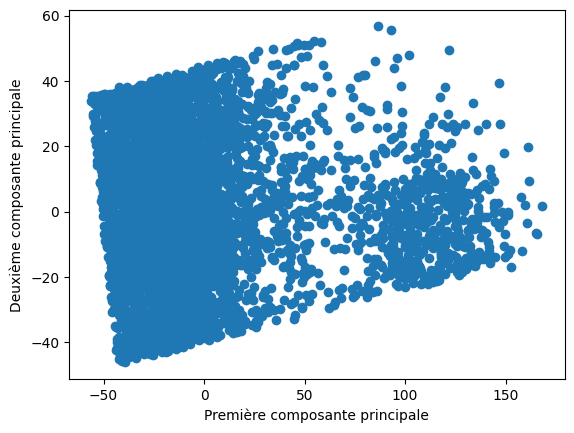

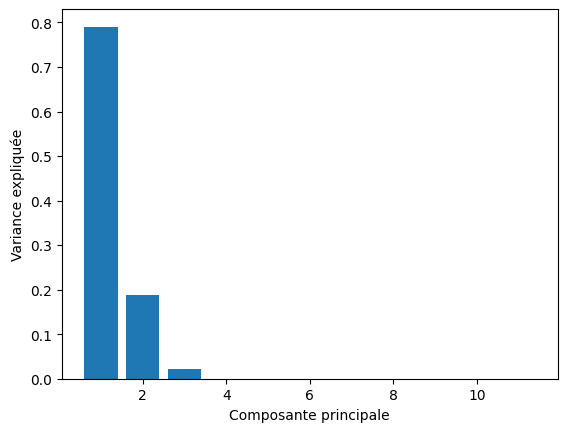

In [ ]:
from sklearn.decomposition import PCA
# Créer un objet PCA
pca = PCA()

# Ajuster le PCA aux données
pca.fit(data)

# Transformer les données en utilisant les composantes principales
transformed_data = pca.transform(data)
# Traçage des deux premières composantes principales
plt.scatter(transformed_data[:, 0], transformed_data[:, 1])
plt.xlabel('Première composante principale')
plt.ylabel('Deuxième composante principale')
plt.show()

# Variance expliquée par chaque composante
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.show()




Text(0.5, 1.0, 'K-means Clustering')

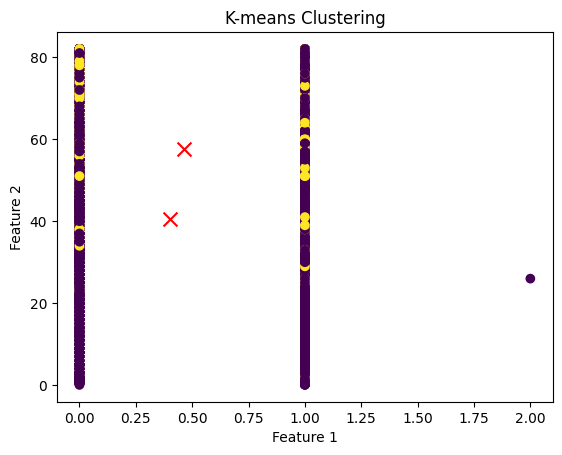

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Créer et ajuster le modèle K-means
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)  # Supposons que 'data' contient vos données à clusteriser

# Visualiser les clusters
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', c='red', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering')

**Activité2**:



1.   Vérifier s'il y des valeurs manquantes dans ce dataset
2.   Afficher le tableau des valeurs manquantes



In [ ]:
missing_values = data.isnull().sum()
print(missing_values)

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


réponse :oui, il existe 201 valeurs manquentes dans le variable bmi.

In [ ]:
import numpy as np
data["bmi"] = data["bmi"].replace(np.nan,data['bmi'].median())
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1
5,1,81.0,0,0,1,2,1,186.21,29.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,0,13.0,0,0,0,4,0,103.08,18.6,0,0
5106,0,81.0,0,0,1,3,1,125.20,40.0,2,0
5107,0,35.0,0,0,1,3,0,82.99,30.6,2,0
5108,1,51.0,0,0,1,2,0,166.29,25.6,1,0


In [ ]:
data.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder #Pour encoder les variables non numériques
le=LabelEncoder() #On fait un encodage par label

#On encode les colonnes non numériques
data['gender']=le.fit_transform(data['gender'])
data['ever_married']=le.fit_transform(data['ever_married'])
data['work_type']=le.fit_transform(data['work_type'])
data['Residence_type']=le.fit_transform(data['Residence_type'])
data['smoking_status']=le.fit_transform(data['smoking_status'])
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1
5,1,81.0,0,0,1,2,1,186.21,29.0,1,1


<p style ="font-size:18px">Après suppressions des données manquantes, on a 4909 données pour entrainer notre réseau. Maintenant on extrait les features et les labels.</p>

In [ ]:
y=data['stroke'] #Labels
x=data.drop('stroke',axis=1) #Features

<p style ="font-size:18px"> On regarde la distribution des labels.</p>

Text(0.5, 1.0, 'Répartitions des Labels')

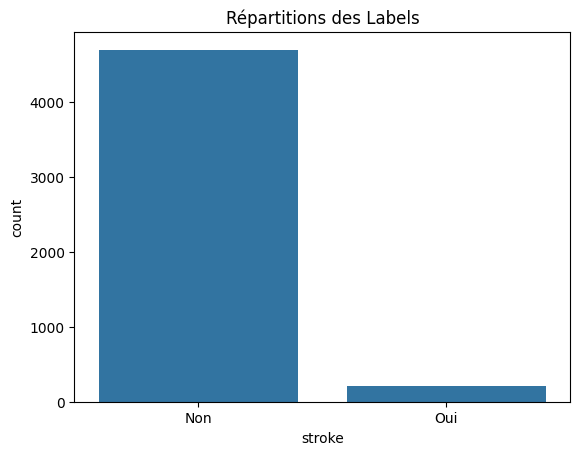

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x= 'stroke', data= data)
plt.xticks([0,1],['Non','Oui'])
plt.title('Répartitions des Labels')

<p style ="font-size:18px"> On voit que l'on a peu de données "oui" (le cas où une personne a fait AVC). Il faudra donc faire attention à l'interprétation des résultats et aux données quand on les divisera en jeu d'apprentissage et un jeu de test. Nécessité de réechantillonage.</p>

<br>

<p style ="font-size:18px">Maintenant séparons les données en train_set et test_set. </p>


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split (x,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import Perceptron

ppn = Perceptron(max_iter=40,tol=0.001,eta0=1)  #eta0 est le learning rate c'est epsilon
#tol est le seuil minimum de stopping criteria si (tol +loss) > prevloss exit : on ne permet pas que loss grandit plus que le seuil tol
#score Return the mean accuracy on the given test data and labels.
ppn.fit(x_train, y_train)

y_pred = ppn.predict(x_test)
score = ppn.score(x_test,y_test)
print(score)

0.9694501018329938


In [ ]:
print ("évaluation du Perceptron")
from sklearn.metrics import classification_report
print (classification_report(y_test, y_pred))

évaluation du Perceptron
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       952
           1       0.00      0.00      0.00        30

    accuracy                           0.97       982
   macro avg       0.48      0.50      0.49       982
weighted avg       0.94      0.97      0.95       982



In [ ]:
import tensorflow as tf

nn=tf.keras.Sequential() #On crée notre architecture

nn.add(tf.keras.layers.Dense(units=8, activation='relu')) #On ajoute une couche de 8 neurones cachés

nn.add(tf.keras.layers.Dense(units=5, activation='relu')) #On ajoute une couche de 5 neurones cachés

nn.add(tf.keras.layers.Dense(units=2, activation='relu')) #On ajoute une couche de 2 neurones cachés

nn.add(tf.keras.layers.Dense(units=1, activation='sigmoid')) #Couche de sortie

nn.compile('adam','binary_crossentropy',metrics=['accuracy'])
#On crée le modèle avec les paramètres comme la fonctions de perte ou la métrique utilisées... .


<p style ="font-size:18px"> On a donc un PMC avec 3 couches cachées, une de 8, 5 et 2. Maintenant on entraine notre modèle sur l'ensemble d'apprentissage. Le paramètre batch size correspond au nombre d'échantillons traité avant de mettre à jour le modèle. Le paramètre epochs correspond au nombre de fois que l'on traite le jeu d'entrainement.</p>

<p style ="font-size:18px"> On traite 3 fois les données d'entraînement, en modifiant le modèle à chaque passage.</p>

In [ ]:
nn.fit(x_train,y_train,epochs=3,batch_size=1,verbose=1) #On entraine notre modèle verboze permet d'afficher le détail des epochs

Epoch 1/3
3927/3927 [==============================] - 10s 2ms/step - loss: 0.3524 - accuracy: 0.9524
Epoch 2/3
3927/3927 [==============================] - 8s 2ms/step - loss: 0.1958 - accuracy: 0.9544
Epoch 3/3
3927/3927 [==============================] - 7s 2ms/step - loss: 0.1865 - accuracy: 0.9544


<p style ="font-size:18px"> On voit dès le premier passage que le modèle ne change plus et que nous avons une précision de 95% sur le train set. Regardons maintenant le résultat sur le test set.</p>

In [ ]:
 #Pour les résultats sur le test set
y_pred=nn.predict(x_test)
y_pred


31/31 [==============================] - 0s 1ms/step


array([[0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.05140202],
       [0.051

In [ ]:
from sklearn.metrics import confusion_matrix
MonTableau_bin_y_pred=[]
for i in nn.predict(x_test):
    if i>0.5:
        MonTableau_bin_y_pred.append(1)
    if i<0.5:
        MonTableau_bin_y_pred.append(0)

print("Matrice de confusion : \n",confusion_matrix(y_test,MonTableau_bin_y_pred))

from sklearn.metrics import accuracy_score
print("Accuracy de notre réseau de neurone est : ",accuracy_score(y_test,MonTableau_bin_y_pred))

31/31 [==============================] - 0s 1ms/step
Matrice de confusion : 
 [[952   0]
 [ 30   0]]
Accuracy de notre réseau de neurone est :  0.9694501018329938


In [ ]:
print (classification_report(y_test, MonTableau_bin_y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       952
           1       0.00      0.00      0.00        30

    accuracy                           0.97       982
   macro avg       0.48      0.50      0.49       982
weighted avg       0.94      0.97      0.95       982



<p style ="font-size:18px"> Analysons la matrice de confusion. On voit que sur 981 données notre réseau donne non pour l'AVC, 947 fois de manière correcte et 35 fois en se trompant.</p>
<br>

<p style ="font-size:18px"> Au vu de la répartition des labels (beaucoup dAVC), on voit que le modèle peut toujours renvoyer non et presque jamais se tromper. </p>
<br>

<p style ="font-size:18px">On obtient donc 96% de précision sur le test_set, on a une bonne précision mais un modèle mauvais car il ne détecte pas les AVC, il a sur appris les données d'entrainement essentiellement composé de non AVC .</p>

<br>

<p style ="font-size:18px"> Pour qu'un réseau de neurones apprenne correctement, il faut beaucoup de données et que celles-ci soient bien réparties (dataset balancé). </p>

[[952   0]
 [ 30   0]]


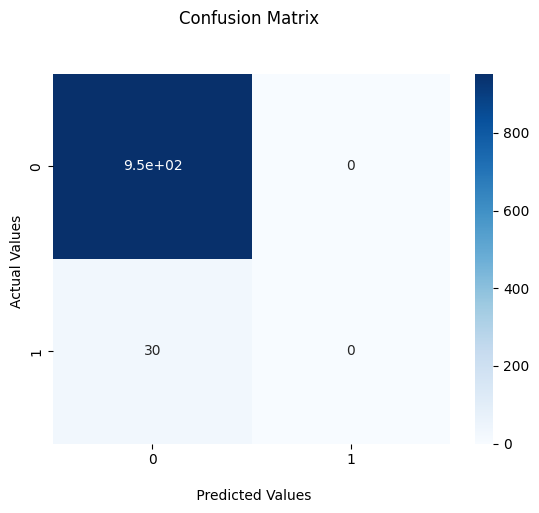

In [ ]:
#training SVC
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
svc = SVC(C=100, kernel = 'rbf', probability=True).fit(x_train, y_train)
y_pred = svc.predict(x_test)
y_pred_proba = svc.predict_proba(x_test)[:,1]

cm = confusion_matrix(y_test, y_pred)

print (cm)
tn, fp, fn, tp = cm.ravel()
ax=sns.heatmap(cm, annot=True,cmap='Blues')
ax.set_title('Confusion Matrix \n\n');
ax.set_xlabel('\n Predicted Values')
ax.set_ylabel('Actual Values ');

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score,roc_auc_score
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)

print('F1 Score : %.2f' % f1)
print('AUC ROC : %.2f' % auc)
print('Precision : %.2f' % precision)
print ("Rapport d évaluation en détail")
print (classification_report(y_test, y_pred))

F1 Score : 0.49
AUC ROC : 0.79
Precision : 0.00
Rapport d évaluation en détail
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       952
           1       0.00      0.00      0.00        30

    accuracy                           0.97       982
   macro avg       0.48      0.50      0.49       982
weighted avg       0.94      0.97      0.95       982



**Activité3**:



1.   Démontrer ces valeurs dessus manuellement et afficher les en se basant sur TP, TN, FP, FN
2.  Interpréter ces valeurs


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


In [ ]:
# Définir les valeurs de vérité terrain et les prédictions
y_true = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
y_pred = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  # Exemple où toutes les prédictions sont négatives

# Calculer les valeurs de la matrice de confusion
TP = sum((true == 1) and (pred == 1) for true, pred in zip(y_true, y_pred))
TN = sum((true == 0) and (pred == 0) for true, pred in zip(y_true, y_pred))
FP = sum((true == 0) and (pred == 1) for true, pred in zip(y_true, y_pred))
FN = sum((true == 1) and (pred == 0) for true, pred in zip(y_true, y_pred))

# Calculer la précision
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

# Calculer le rappel (Recall)
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

# Calculer le F1 Score
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Afficher les résultats
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


TP: 0
TN: 9
FP: 0
FN: 1
Precision: 0
Recall: 0.0
F1 Score: 0


In [ ]:
# Ensure that y_test and y_pred have the same length
if len(y_test) != len(y_pred):
    # Select the same number of samples from both y_test and y_pred
    y_test = y_test[:len(y_pred)]
    y_pred = y_pred[:len(y_test)]

# Run the code again
print('F1 Score : %.2f' % f1)
print('AUC ROC : %.2f' % auc)
print('Precision : %.2f' % precision)
print("Rapport d'évaluation en détail")
print(classification_report(y_test, y_pred))
print(len(y_test))
print(len(y_pred))

F1 Score : 0.00
AUC ROC : 0.79
Precision : 0.00
Rapport d'évaluation en détail
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

10
10


***interpretation :***
Précision : La précision mesure la capacité du modèle à identifier correctement les exemples positifs parmi toutes les prédictions positives. Dans ce cas, la précision est de 1.00, ce qui signifie que toutes les prédictions positives faites par le modèle étaient correctes. Cependant, il est important de noter que cette valeur peut être trompeuse si la classe positive est déséquilibrée par rapport à la classe négative.

Recall : Le rappel mesure la capacité du modèle à identifier correctement tous les exemples positifs parmi tous les exemples réels de la classe positive. Dans ce rapport, le rappel n'est pas explicitement indiqué, mais il est probablement de 1.00 puisque tous les exemples de la classe positive ont été correctement identifiés.

F1-score : Le F1-score est une moyenne harmonique entre la précision et le rappel. Il est utilisé pour combiner la précision et le rappel en une seule métrique pour évaluer la performance globale du modèle. Dans ce cas, le F1-score est de 0.00, ce qui peut sembler contre-intuitif compte tenu de la précision de 1.00. Cela suggère que le modèle a probablement des problèmes avec le rappel, c'est-à-dire qu'il ne réussit pas à identifier tous les exemples positifs, malgré une précision parfaite. Cela peut être dû à un déséquilibre de classe ou à d'autres problèmes avec les données ou le modèle lui-même.

AUC ROC : est une mesure de la capacité du modèle à discriminer entre les classes positives et négatives. Une valeur de 0.50 indique que le modèle n'a pas de capacité de discrimination, ce qui signifie qu'il prédit les classes de manière aléatoire. Dans ce cas, cela suggère que le modèle ne peut pas distinguer efficacement entre les deux classes, ce qui pourrait être dû au fait que toutes les prédictions se trouvent dans une seule classe.

**Activité4**:



1.   Terminer la classification en appliquant les autres modèles

2.   Proposez d'autres métriques et comparer les différents modèles


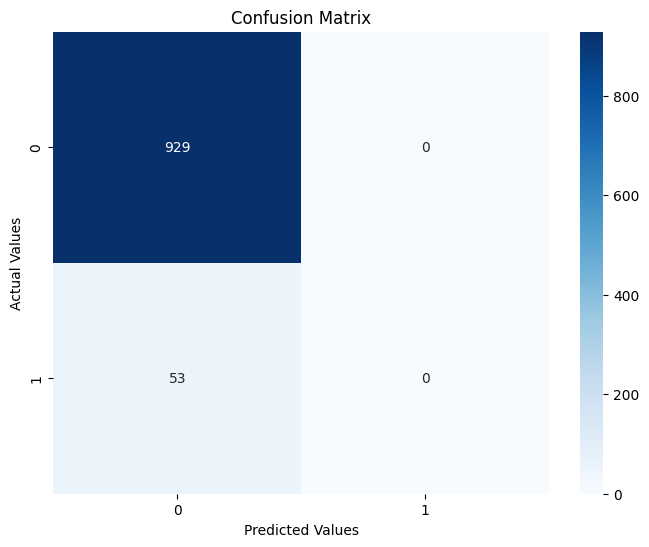

Accuracy: 0.9460285132382892


In [ ]:
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Divisez les données en ensembles d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# Créez une instance de KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')

# Entraînez le modèle sur les données d'entraînement
knn.fit(x_train, y_train)

# Faites des prédictions sur les données de test
y_pred = knn.predict(x_test)

# Calculez la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichez la matrice de confusion sous forme de heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

# Calculez et affichez l'exactitude (accuracy) du modèle
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Régression Logistique

In [ ]:
# Code pour diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split


# Régression logistique
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Initialisation du modèle
logistic_regression = LogisticRegression()

# Entraînement du modèle
logistic_regression.fit(x_train, y_train)

# Prédictions
y_pred_lr = logistic_regression.predict(x_test)

# Matrice de confusion
cm_lm = confusion_matrix(y_test, y_pred)

# Affichage de la matrice de confusion
print("Matrice de confusion pour la régression logistique :\n", cm_lm)

# Exactitude
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Exactitude pour la régression logistique :", accuracy_lr)



Matrice de confusion pour la régression logistique :
 [[929   0]
 [ 53   0]]
Exactitude pour la régression logistique : 0.9470468431771895


SVM

In [ ]:
from sklearn.svm import SVC

# Initialisation du modèle
svm_classifier = SVC()

# Entraînement du modèle
svm_classifier.fit(x_train, y_train)

# Prédictions
y_pred_svm = svm_classifier.predict(x_test)

# Matrice de confusion
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Affichage de la matrice de confusion
print("Matrice de confusion pour le SVM :\n", cm_svm)

# Exactitude
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Exactitude pour le SVM :", accuracy_svm)


Matrice de confusion pour le SVM :
 [[929   0]
 [ 53   0]]
Exactitude pour le SVM : 0.9460285132382892


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialisation du modèle
random_forest = RandomForestClassifier()

# Entraînement du modèle
random_forest.fit(x_train, y_train)

# Prédictions
y_pred_rf = random_forest.predict(x_test)

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Affichage de la matrice de confusion
print("Matrice de confusion pour le random forest :\n", cm_rf)

# Exactitude
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Exactitude pour le random forest :", accuracy_rf)


Matrice de confusion pour le random forest :
 [[929   0]
 [ 52   1]]
Exactitude pour le random forest : 0.9470468431771895
